In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [58]:
digits = load_digits()

X = digits.data       
y = digits.target
images = digits.images # actual images

print("Dataset shape:", X.shape)

Dataset shape: (1797, 64)


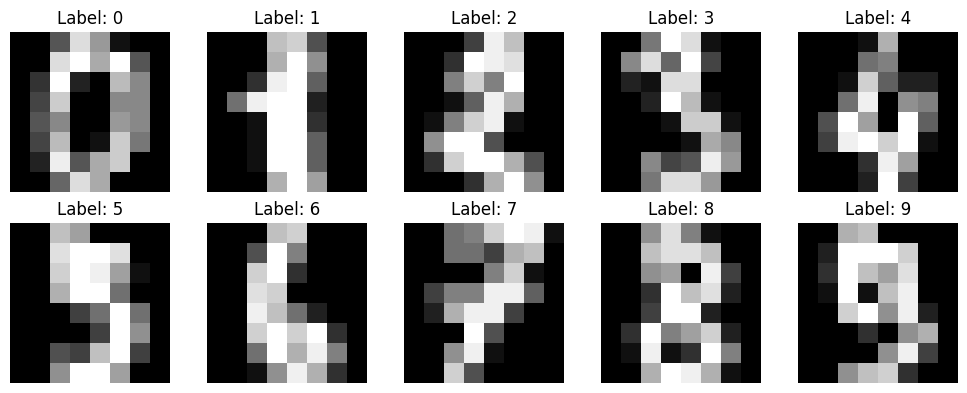

In [59]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

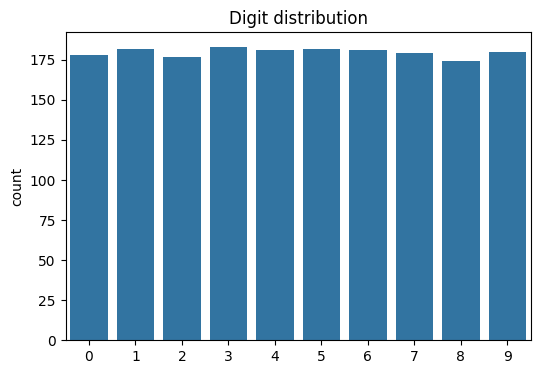

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Digit distribution")
plt.show()

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    
)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [63]:
model_without = LogisticRegression(max_iter=5000)
model_without.fit(X_train_scaled, y_train)

y_pred_without = model_without.predict(X_test_scaled)
acc_without = accuracy_score(y_test, y_pred_without)

print("Accuracy WITHOUT SVD:", acc_without)

Accuracy WITHOUT SVD: 0.9722222222222222


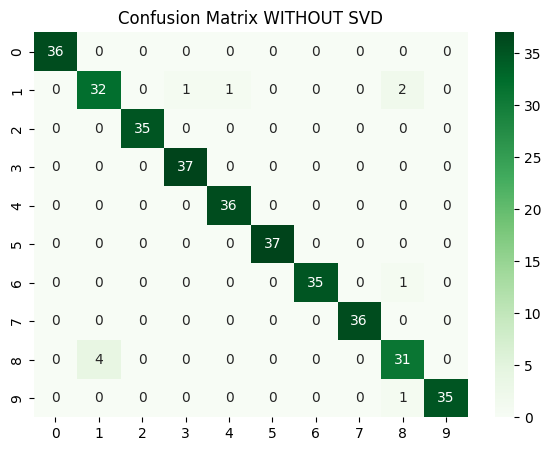

In [64]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_without),
            annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix WITHOUT SVD")
plt.show()

In [65]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=30)
X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

In [66]:
print("Original features:", X_train.shape[1])
print("Reduced features after SVD:", X_train_svd.shape[1])

Original features: 64
Reduced features after SVD: 30


In [67]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train_svd, y_train)

LogisticRegression(max_iter=5000)

In [68]:
y_pred_with = model.predict(X_test_svd)
print("Accuracy with SVD:", accuracy_score(y_test, y_pred_with))

Accuracy with SVD: 0.9527777777777777


In [69]:
print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

Explained variance ratio: 0.8933064101253946


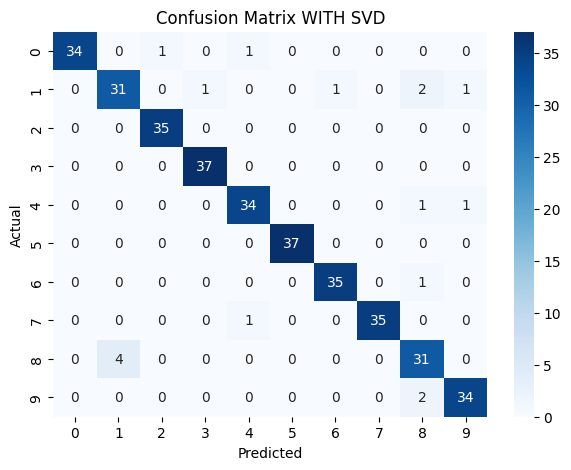

In [70]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_with), 
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix WITH SVD")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
print("\nFINAL COMPARISON")
print("----------------------")
print("Accuracy WITHOUT SVD :", acc_without)
print("Accuracy WITH SVD    :", accuracy_score(y_test, y_pred_with))



FINAL COMPARISON
----------------------
Accuracy WITHOUT SVD : 0.9722222222222222
Accuracy WITH SVD    : 0.9527777777777777
